# **Cours :** INF 5103 Concepts statistiques pour la science des données


**TP –  :**

**Date limite pour remettre votre travail : **

**Modalités de travail:**

1.  Les TDevoirs se feront individuellement sur Python.
2.  La remise des Devoirs doit se faire sur Moodle.
3.  Un retard de remise de $n$ journées va causer la perte de $20 n$ points.  

**Livrable**

Retouner ce fichier avec les cellules remplies.


## Partie 1 : Modèle linéaire pour la régression

**Description des données:**

Les données ont été échantillonnées à partir d’une fonction à deux dimensions $f(x_1, x_2)$ où $x_1$ et $x_2$ sont deux attributs. Elles sont données dans un fichier .CSV contenant 200 instances de données et trois colonnes. Les deux premières colonnes décrivent les attributs $x_1$ et $x_2$ et la troisième colonne décrit la variable cible $y$. 

**Implantation demandée**

En utilisant la programmation avec Python et les fonctions de la librairie `scikit-learn`, on vous demande de réaliser les quatre régressions suivantes:

1.   **Une régression ordinaire** avec une fonction polynômiale d’ordre 10.

2.   **Une régression par crête** (ridge regression) avec une fonction polynômiale d’ordre 10.

3.   **Une régression Lasso** (Lasso regression) avec une fonction polynômiale d’ordre 10

4.   **Une régression Elasticnet** (Elasticnet regression) avec une fonction polynômiale d’ordre 10

Utiliser $80\%$ des données pour l'entrainement et $20\%$ des données pour le test et afficher l'erreur de régression pour chaque modèle.

**Instructions:**

Utiliser les fonctions suivantes pour l'implantation de votre code:

*   `LinearRegression()`, `Ridge`  et `Lasso`, 'elasticne' (de `sklearn.linear_model`) pour implanter les régressions.

*   `PolynomialFeatures` (de `sklearn.preprocessing`) pour générer les attributs des fonctions polynômiales.

*   `train_test_split` (de `sklearn.model_selection`) pour diviser les données en partie entrainement et partie test.
*   `mean_squared_error` (de `sklearn.metrics`)  pour calculer la moyenne des  écarts pour les différents types de régressions.

La cellule suivante montre comment lire les données du fichier CSV dans un dataFrame et afficher le nuage des données en 3D. 

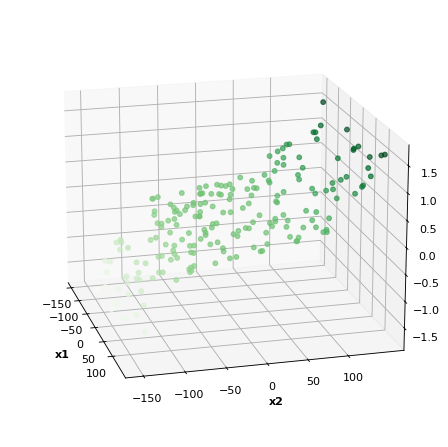

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score # moidre carré et coef de determination
from sklearn.linear_model import LinearRegression,Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.pipeline import make_pipeline

# Lecture des données  "C:\\Users\\Naouel\\Downloads\\DEVOIRStatistique\\DEVOIR\\Devoir partie 1\my_data.csv"
df = pd.read_csv("C:\\Users\\Naouel\\Downloads\\DEVOIRStatistique\\DEVOIR\\Devoir partie 1\\my_data.csv")
X = df.to_numpy()[:,:2]
y = df.to_numpy()[:,2]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)


# Affichage des données
plt.figure(figsize=(10,7), dpi=80)


ax = plt.axes(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], y, c=y, cmap='Greens', s=18, alpha=0.7)



ax.set_xlabel('x1',  fontsize=10.0, fontweight='bold')
ax.set_ylabel('x2',  fontsize=10.0, fontweight='bold')
ax.set_zlabel('y',   fontsize=10.0, fontweight='bold')

plt.xticks(np.arange(-150, 150, step=50))
plt.yticks(np.arange(-150, 150, step=50))

ax.view_init(18,-15)

**Une régression ordinaire**

=== Régression polynomiale (ordre 10) ===
MSE (train) : 0.000
MSE (test)  : 0.000
R2  (train) : 1.0000
R2  (test)  : 1.0000
Intercept (w0): 148155.87830000042
Features     : ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2' 'x1^3' 'x1^2 x2' 'x1 x2^2' 'x2^3' 'x1^4'
 'x1^3 x2' 'x1^2 x2^2' 'x1 x2^3' 'x2^4' 'x1^5' 'x1^4 x2' 'x1^3 x2^2'
 'x1^2 x2^3' 'x1 x2^4' 'x2^5' 'x1^6' 'x1^5 x2' 'x1^4 x2^2' 'x1^3 x2^3'
 'x1^2 x2^4' 'x1 x2^5' 'x2^6' 'x1^7' 'x1^6 x2' 'x1^5 x2^2' 'x1^4 x2^3'
 'x1^3 x2^4' 'x1^2 x2^5' 'x1 x2^6' 'x2^7' 'x1^8' 'x1^7 x2' 'x1^6 x2^2'
 'x1^5 x2^3' 'x1^4 x2^4' 'x1^3 x2^5' 'x1^2 x2^6' 'x1 x2^7' 'x2^8' 'x1^9'
 'x1^8 x2' 'x1^7 x2^2' 'x1^6 x2^3' 'x1^5 x2^4' 'x1^4 x2^5' 'x1^3 x2^6'
 'x1^2 x2^7' 'x1 x2^8' 'x2^9' 'x1^10' 'x1^9 x2' 'x1^8 x2^2' 'x1^7 x2^3'
 'x1^6 x2^4' 'x1^5 x2^5' 'x1^4 x2^6' 'x1^3 x2^7' 'x1^2 x2^8' 'x1 x2^9'
 'x2^10']
Coefficients : [-7.68250059e+02 -1.00789371e+03  1.88578477e+04 -4.54404624e-04
  8.63664318e-05  7.85814249e-04  8.21585767e-04 -8.39749991e-04
  6.11243657e+06 -7.64906686

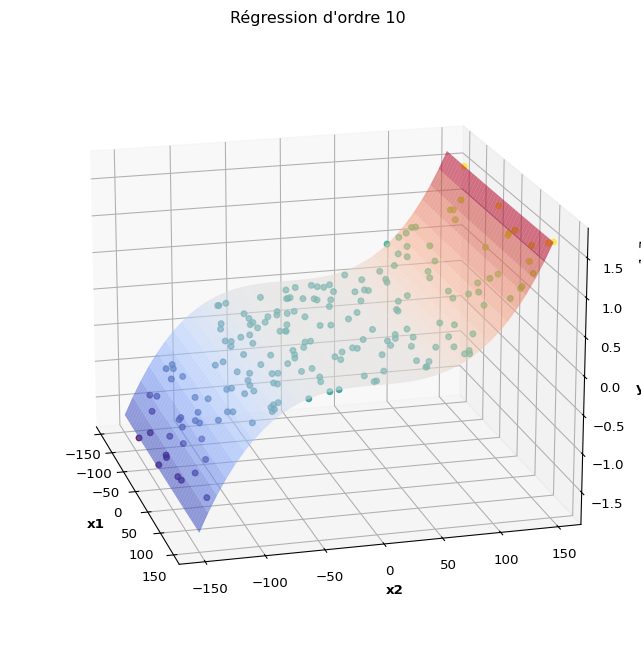

In [ ]:

# Régression polynomiale d'ORDRE 10

#1) Régression polynomiale 

reg1=make_pipeline(PolynomialFeatures(10,include_bias=False),# le false c'est pour eviter le double biais
                   StandardScaler(),
                   LinearRegression())


# 2) Entraînement
reg1.fit(X_train, y_train)

# 3) Évaluation train/test
y_pred_tr = reg1.predict(X_train)
y_pred_te = reg1.predict(X_test)

mse_tr1 = mean_squared_error(y_train, y_pred_tr)
mse_te1 = mean_squared_error(y_test,  y_pred_te)
r2_tr  = r2_score(y_train, y_pred_tr)
r2_te  = r2_score(y_test,  y_pred_te)

# 4) Affichage des résultats
print("=== Régression polynomiale (ordre 10) ===")
print(f"MSE (train) : {mse_tr1:.3f}")
print(f"MSE (test)  : {mse_te1:.3f}")
print(f"R2  (train) : {r2_tr:.4f}")
print(f"R2  (test)  : {r2_te:.4f}")

poly = reg1.named_steps['polynomialfeatures']
lin  = reg1.named_steps['linearregression']

names = poly.get_feature_names_out(['x1','x2'])
print("Intercept (w0):", lin.intercept_)
print("Features     :", names)
print("Coefficients :", lin.coef_)  # même ordre que 'names'

# Tracé de la surface 3D de plan 
n_grid = 40
x1_lin = np.linspace(X[:, 0].min(), X[:, 0].max(), n_grid)
x2_lin = np.linspace(X[:, 1].min(), X[:, 1].max(), n_grid)
x1_grid, x2_grid = np.meshgrid(x1_lin, x2_lin)

X_grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]
y_grid = reg1.predict(X_grid).reshape(x1_grid.shape)  # c'est ici qu'on met l'equation de la regression. Gràce à reg1.predict(X_grid)

fig = plt.figure(figsize=(10, 7), dpi=96)
ax = fig.add_subplot(111, projection='3d')

# Nuage de points 
ax.scatter3D(X[:,0], X[:,1], y, c=y, cmap='viridis', s=18, alpha=0.7)

# Surface du plan
surf = ax.plot_surface(
    x1_grid, x2_grid, y_grid,
    cmap='coolwarm', alpha=0.55, linewidth=0, antialiased=True
)

ax.set_title("Régression d'ordre 10 ")
ax.set_xlabel('x1', fontweight='bold')
ax.set_ylabel('x2', fontweight='bold')
ax.set_zlabel('y',  fontweight='bold')
ax.view_init(elev=18, azim=-15)
plt.tight_layout()
plt.show()

**Une régression par crête**

=== Régression Ridge (ordre 10) ===
MSE (train) : 22284715164.376
MSE (test)  : 64303389542.341
R2  (train) : 0.9994
R2  (test)  : 0.9988
Intercept (w0): 148155.87830000024
Features     : ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2' 'x1^3' 'x1^2 x2' 'x1 x2^2' 'x2^3' 'x1^4'
 'x1^3 x2' 'x1^2 x2^2' 'x1 x2^3' 'x2^4' 'x1^5' 'x1^4 x2' 'x1^3 x2^2'
 'x1^2 x2^3' 'x1 x2^4' 'x2^5' 'x1^6' 'x1^5 x2' 'x1^4 x2^2' 'x1^3 x2^3'
 'x1^2 x2^4' 'x1 x2^5' 'x2^6' 'x1^7' 'x1^6 x2' 'x1^5 x2^2' 'x1^4 x2^3'
 'x1^3 x2^4' 'x1^2 x2^5' 'x1 x2^6' 'x2^7' 'x1^8' 'x1^7 x2' 'x1^6 x2^2'
 'x1^5 x2^3' 'x1^4 x2^4' 'x1^3 x2^5' 'x1^2 x2^6' 'x1 x2^7' 'x2^8' 'x1^9'
 'x1^8 x2' 'x1^7 x2^2' 'x1^6 x2^3' 'x1^5 x2^4' 'x1^4 x2^5' 'x1^3 x2^6'
 'x1^2 x2^7' 'x1 x2^8' 'x2^9' 'x1^10' 'x1^9 x2' 'x1^8 x2^2' 'x1^7 x2^3'
 'x1^6 x2^4' 'x1^5 x2^5' 'x1^4 x2^6' 'x1^3 x2^7' 'x1^2 x2^8' 'x1 x2^9'
 'x2^10']
Coefficients : [-6.18341578e+04  9.00381666e+05  2.16655071e+04  1.39719474e+04
  3.48051056e+04  1.02148617e+05 -2.51713064e+05  3.33897647e+04
  3.33700120e+

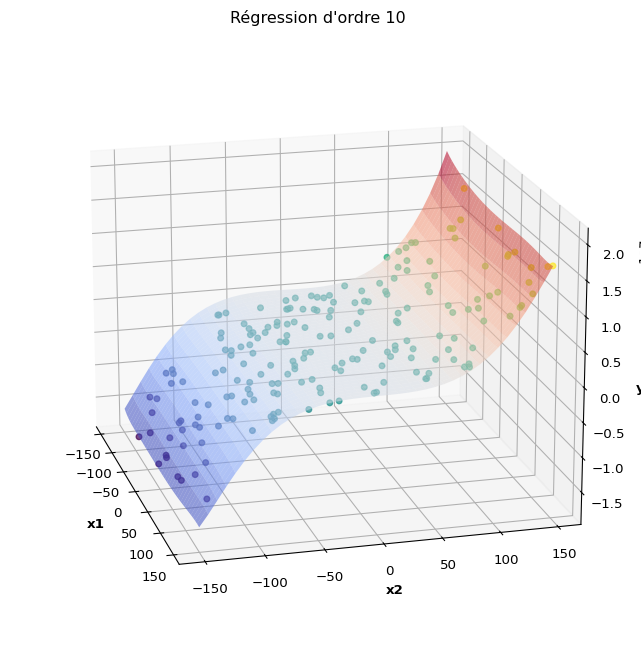

In [3]:
# Régression Ridge (ordre 10)

ridge_reg = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    StandardScaler(),
    Ridge(alpha=1.0)   # alpha = coefficient de régularisation
)

# Entraînement
ridge_reg.fit(X_train, y_train)

# Prédictions
y_pred_tr = ridge_reg.predict(X_train)
y_pred_te = ridge_reg.predict(X_test)

# Évaluation
mse_tr = mean_squared_error(y_train, y_pred_tr)
mse_te = mean_squared_error(y_test, y_pred_te)
r2_tr  = r2_score(y_train, y_pred_tr)
r2_te  = r2_score(y_test, y_pred_te)

# Affichage
print("=== Régression Ridge (ordre 10) ===")
print(f"MSE (train) : {mse_tr:.3f}")
print(f"MSE (test)  : {mse_te:.3f}")
print(f"R2  (train) : {r2_tr:.4f}")
print(f"R2  (test)  : {r2_te:.4f}")

# Interprétation du modèle
poly = ridge_reg.named_steps['polynomialfeatures']
ridge = ridge_reg.named_steps['ridge']

names = poly.get_feature_names_out(['x1', 'x2'])

print("Intercept (w0):", ridge.intercept_)
print("Features     :", names)
print("Coefficients :", ridge.coef_)

# Tracé de la surface 3D de plan 
n_grid = 40
x1_lin = np.linspace(X[:, 0].min(), X[:, 0].max(), n_grid)
x2_lin = np.linspace(X[:, 1].min(), X[:, 1].max(), n_grid)
x1_grid, x2_grid = np.meshgrid(x1_lin, x2_lin)

X_grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]
y_grid = ridge_reg.predict(X_grid).reshape(x1_grid.shape)  # c'est ici qu'on met l'equation du plan. Gràce à reg1.predict(X_grid)

fig = plt.figure(figsize=(10, 7), dpi=96)
ax = fig.add_subplot(111, projection='3d')
# Nuage de points 
ax.scatter3D(X[:,0], X[:,1], y, c=y, cmap='viridis', s=18, alpha=0.7)

# Surface du plan
surf = ax.plot_surface(
    x1_grid, x2_grid, y_grid,
    cmap='coolwarm', alpha=0.55, linewidth=0, antialiased=True
)

ax.set_title("Régression d'ordre 10 ")
ax.set_xlabel('x1', fontweight='bold')
ax.set_ylabel('x2', fontweight='bold')
ax.set_zlabel('y',  fontweight='bold')
ax.view_init(elev=18, azim=-15)
plt.tight_layout()
plt.show()

**Une régression LASSO**

=== Régression Lasso (ordre 10) ===
MSE (train) : 1128679932.794
MSE (test)  : 31546487583.102
R2  (train) : 1.0000
R2  (test)  : 0.9994
Intercept (w0): 148155.87830000004
Features     : ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2' 'x1^3' 'x1^2 x2' 'x1 x2^2' 'x2^3' 'x1^4'
 'x1^3 x2' 'x1^2 x2^2' 'x1 x2^3' 'x2^4' 'x1^5' 'x1^4 x2' 'x1^3 x2^2'
 'x1^2 x2^3' 'x1 x2^4' 'x2^5' 'x1^6' 'x1^5 x2' 'x1^4 x2^2' 'x1^3 x2^3'
 'x1^2 x2^4' 'x1 x2^5' 'x2^6' 'x1^7' 'x1^6 x2' 'x1^5 x2^2' 'x1^4 x2^3'
 'x1^3 x2^4' 'x1^2 x2^5' 'x1 x2^6' 'x2^7' 'x1^8' 'x1^7 x2' 'x1^6 x2^2'
 'x1^5 x2^3' 'x1^4 x2^4' 'x1^3 x2^5' 'x1^2 x2^6' 'x1 x2^7' 'x2^8' 'x1^9'
 'x1^8 x2' 'x1^7 x2^2' 'x1^6 x2^3' 'x1^5 x2^4' 'x1^4 x2^5' 'x1^3 x2^6'
 'x1^2 x2^7' 'x1 x2^8' 'x2^9' 'x1^10' 'x1^9 x2' 'x1^8 x2^2' 'x1^7 x2^3'
 'x1^6 x2^4' 'x1^5 x2^5' 'x1^4 x2^6' 'x1^3 x2^7' 'x1^2 x2^8' 'x1 x2^9'
 'x2^10']
Coefficients : [-1.56473957e+04  1.06703117e+05  8.33412075e+04  1.11458491e+04
  2.40624373e+04  4.84801194e+04  3.70927605e+05  1.20518533e+05
  5.29951057e+0

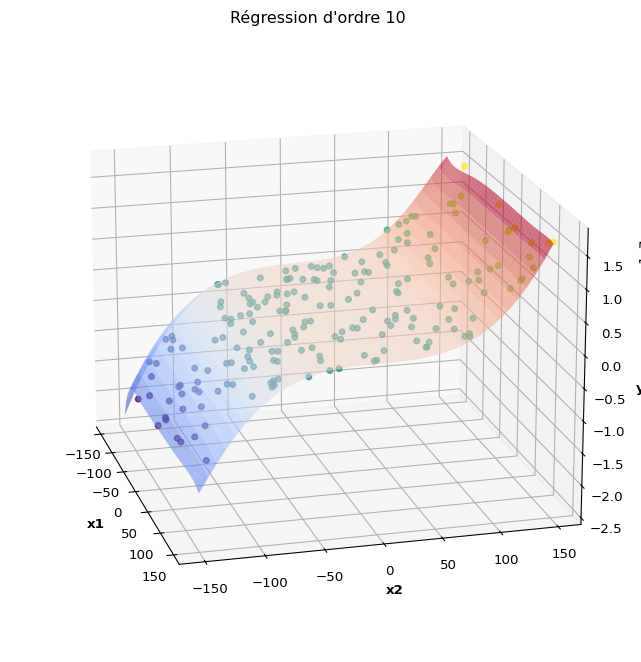

In [4]:
# Régression Lasso (ordre 10)
lasso_reg = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    StandardScaler(),
    Lasso(alpha=0.01, max_iter=10000)  # alpha = régularisation, max_iter pour convergence
)

# Entraînement
lasso_reg.fit(X_train, y_train)

# Prédictions
y_pred_tr = lasso_reg.predict(X_train)
y_pred_te = lasso_reg.predict(X_test)

# Évaluation
mse_tr = mean_squared_error(y_train, y_pred_tr)
mse_te = mean_squared_error(y_test, y_pred_te)
r2_tr  = r2_score(y_train, y_pred_tr)
r2_te  = r2_score(y_test, y_pred_te)

# Affichage
print("=== Régression Lasso (ordre 10) ===")
print(f"MSE (train) : {mse_tr:.3f}")
print(f"MSE (test)  : {mse_te:.3f}")
print(f"R2  (train) : {r2_tr:.4f}")
print(f"R2  (test)  : {r2_te:.4f}")

# Interprétation
poly = lasso_reg.named_steps['polynomialfeatures']
lasso = lasso_reg.named_steps['lasso']

names = poly.get_feature_names_out(['x1', 'x2'])

print("Intercept (w0):", lasso.intercept_)
print("Features     :", names)
print("Coefficients :", lasso.coef_)


# Tracé de la surface 3D de plan 
n_grid = 40
x1_lin = np.linspace(X[:, 0].min(), X[:, 0].max(), n_grid)
x2_lin = np.linspace(X[:, 1].min(), X[:, 1].max(), n_grid)
x1_grid, x2_grid = np.meshgrid(x1_lin, x2_lin)

X_grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]
y_grid = lasso_reg.predict(X_grid).reshape(x1_grid.shape)  # c'est ici qu'on met l'equation du plan. Gràce à reg1.predict(X_grid)

fig = plt.figure(figsize=(10, 7), dpi=96)
ax = fig.add_subplot(111, projection='3d')
# Nuage de points 
ax.scatter3D(X[:,0], X[:,1], y, c=y, cmap='viridis', s=18, alpha=0.7)

# Surface du plan
surf = ax.plot_surface(
    x1_grid, x2_grid, y_grid,
    cmap='coolwarm', alpha=0.55, linewidth=0, antialiased=True
)

ax.set_title("Régression d'ordre 10 ")
ax.set_xlabel('x1', fontweight='bold')
ax.set_ylabel('x2', fontweight='bold')
ax.set_zlabel('y',  fontweight='bold')
ax.view_init(elev=18, azim=-15)
plt.tight_layout()
plt.show()

**Une régression Elasticnet** 

=== Régression ElasticNet (ordre 10) ===
MSE (train) : 156792159320.145
MSE (test)  : 583221237819.797
R2  (train) : 0.9958
R2  (test)  : 0.9896
Intercept (w0): 148155.8783
Features     : ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2' 'x1^3' 'x1^2 x2' 'x1 x2^2' 'x2^3' 'x1^4'
 'x1^3 x2' 'x1^2 x2^2' 'x1 x2^3' 'x2^4' 'x1^5' 'x1^4 x2' 'x1^3 x2^2'
 'x1^2 x2^3' 'x1 x2^4' 'x2^5' 'x1^6' 'x1^5 x2' 'x1^4 x2^2' 'x1^3 x2^3'
 'x1^2 x2^4' 'x1 x2^5' 'x2^6' 'x1^7' 'x1^6 x2' 'x1^5 x2^2' 'x1^4 x2^3'
 'x1^3 x2^4' 'x1^2 x2^5' 'x1 x2^6' 'x2^7' 'x1^8' 'x1^7 x2' 'x1^6 x2^2'
 'x1^5 x2^3' 'x1^4 x2^4' 'x1^3 x2^5' 'x1^2 x2^6' 'x1 x2^7' 'x2^8' 'x1^9'
 'x1^8 x2' 'x1^7 x2^2' 'x1^6 x2^3' 'x1^5 x2^4' 'x1^4 x2^5' 'x1^3 x2^6'
 'x1^2 x2^7' 'x1 x2^8' 'x2^9' 'x1^10' 'x1^9 x2' 'x1^8 x2^2' 'x1^7 x2^3'
 'x1^6 x2^4' 'x1^5 x2^5' 'x1^4 x2^6' 'x1^3 x2^7' 'x1^2 x2^8' 'x1 x2^9'
 'x2^10']
Coefficients : [-1.98922053e+04  1.41169998e+06 -4.81185401e+03  5.08866635e+04
 -5.99455670e+04  3.01290807e+04  3.44127615e+03  7.70308746e+04
  2.13352835e+

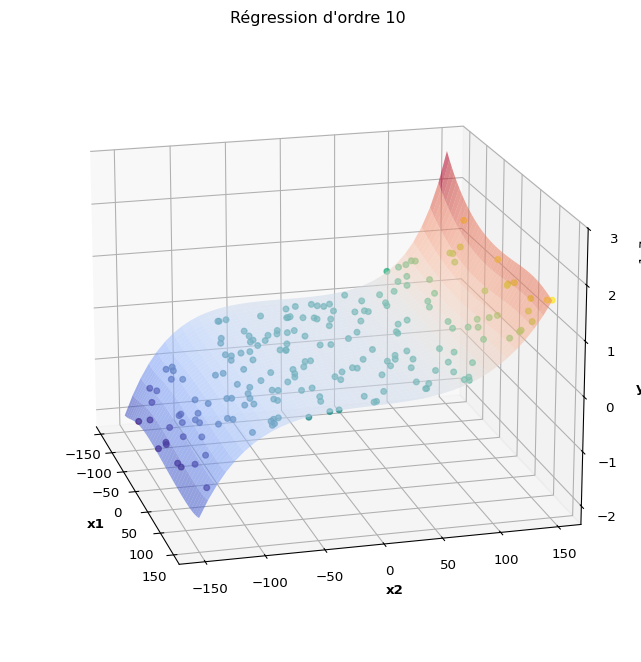

In [5]:
# Régression ElasticNet (ordre 10)
en_reg = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    StandardScaler(),
    ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)  # l1_ratio=0.5 => 50% L1 + 50% L2
)

# Entraînement
en_reg.fit(X_train, y_train)

# Prédictions
y_pred_tr = en_reg.predict(X_train)
y_pred_te = en_reg.predict(X_test)

# Évaluation
mse_tr = mean_squared_error(y_train, y_pred_tr)
mse_te = mean_squared_error(y_test, y_pred_te)
r2_tr  = r2_score(y_train, y_pred_tr)
r2_te  = r2_score(y_test, y_pred_te)

# Affichage
print("=== Régression ElasticNet (ordre 10) ===")
print(f"MSE (train) : {mse_tr:.3f}")
print(f"MSE (test)  : {mse_te:.3f}")
print(f"R2  (train) : {r2_tr:.4f}")
print(f"R2  (test)  : {r2_te:.4f}")

# Interprétation
poly = en_reg.named_steps['polynomialfeatures']
en = en_reg.named_steps['elasticnet']

names = poly.get_feature_names_out(['x1', 'x2'])

print("Intercept (w0):", en.intercept_)
print("Features     :", names)
print("Coefficients :", en.coef_)


# Tracé de la surface 3D de plan 
n_grid = 40
x1_lin = np.linspace(X[:, 0].min(), X[:, 0].max(), n_grid)
x2_lin = np.linspace(X[:, 1].min(), X[:, 1].max(), n_grid)
x1_grid, x2_grid = np.meshgrid(x1_lin, x2_lin)

X_grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]
y_grid = en_reg.predict(X_grid).reshape(x1_grid.shape)  # c'est ici qu'on met l'equation du plan. Gràce à reg1.predict(X_grid)

fig = plt.figure(figsize=(10, 7), dpi=96)
ax = fig.add_subplot(111, projection='3d')
# Nuage de points 
ax.scatter3D(X[:,0], X[:,1], y, c=y, cmap='viridis', s=18, alpha=0.7)

# Surface du plan
surf = ax.plot_surface(
    x1_grid, x2_grid, y_grid,
    cmap='coolwarm', alpha=0.55, linewidth=0, antialiased=True
)

ax.set_title("Régression d'ordre 10 ")
ax.set_xlabel('x1', fontweight='bold')
ax.set_ylabel('x2', fontweight='bold')
ax.set_zlabel('y',  fontweight='bold')
ax.view_init(elev=18, azim=-15)
plt.tight_layout()
plt.show()

## Partie II  : Classification

**Description des données:**

La description est sur le site : https://archive.ics.uci.edu/ml/datasets/Spambase 

L’ensemble des données contient 4601 instances d’emails. Chaque email est décrit par 57 attributs dans R calculé sur le texte de l’email.   

*  48 attributs représentant les fréquences mots (ex. internet, money, etc.)   
*  06 attributs représentant les fréquences de caractères spéciaux (ex. ;, \$, etc.).
 etc.)
*  03 attributs de statistiques sur la longueur de séquences en majuscules. 
*  La dernière colonne donne l’étiquette de la classe (1 : spam, 0 : ham).


**Implantation demandée**

Utiliser une validation croisée en $m=3$ plis, et donner pour chaque algorithme l’erreur de validation moyenne.
 
*   Classificateur de Bayes
*   Régression logistique
*   Réseaux de neurones

**Instructions:**

1) Utiliser les fonctions de Pandas pour résumer les statistiques importantes de l'ensemble des données. 

2) Utiliser les fonctions suivantes pour l'implantation de votre code:


*   `GaussianNB` (de `sklearn.naive_bayes.GaussianNB`) pour implanter le classifieur de Bayes.

*  `LogisticRegression` (de `sklearn.linear_model.LogisticRegression`) pour implanter la régression logistique.

*  `MLPClassifier` (de `sklearn.neural_network`) pour implanter les réseaux de neurones.

*   `cross_validate` (de `sklearn.model_selection`) pour générer la validation croisée en utilisant les plis.



In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split,cross_val_score,cross_validate,learning_curve
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler as ROS # training data oversampling
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline

path = r"C:\\Users\\Naouel\\Downloads\\DEVOIRStatistique\\DEVOIR\\Devoir partie 1\\spambase.data"

df = pd.read_csv(path, header=None)

df.head()

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42, stratify=y)



57
0    0.605955
1    0.394045
Name: proportion, dtype: float64


Régression Logistique

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       558
           1       0.89      0.91      0.90       363

    accuracy                           0.92       921
   macro avg       0.91      0.92      0.92       921
weighted avg       0.92      0.92      0.92       921

   fit_time  score_time  test_accuracy  test_precision  test_recall   test_f1
0  0.089476    0.020853       0.920469        0.912821     0.882645  0.897479
1  0.052914    0.033301       0.913950        0.855422     0.940397  0.895899
2  0.086808    0.029067       0.866928        0.796736     0.889073  0.840376


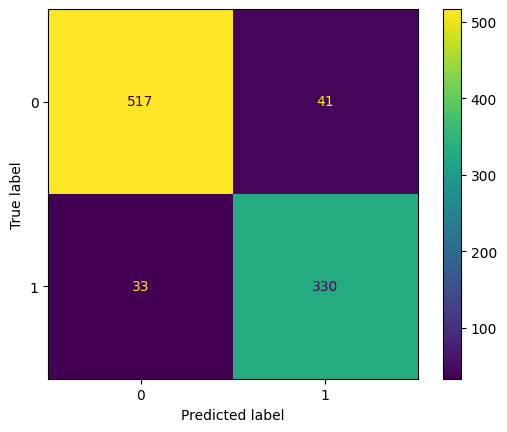

In [7]:
#Regression Logistique

RL_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ros', ROS(random_state=42)),# doit-on le maintenir ou pas? les classes ne sont pas déséquilibrées
    ('model', LogisticRegression(max_iter=500))
])

RL_pipeline.fit(X_train, y_train)
y_pred_RL = RL_pipeline.predict(X_test)

print("Régression Logistique\n")
print(classification_report(y_test, y_pred_RL))

cm = confusion_matrix(y_test, y_pred_RL)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
scores = cross_validate(
    RL_pipeline,
    X,
    y,
    cv=3,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)
scores_df = pd.DataFrame(scores)
print(scores_df)



Naive Bayes

              precision    recall  f1-score   support

           0       0.96      0.75      0.84       558
           1       0.71      0.95      0.81       363

    accuracy                           0.83       921
   macro avg       0.84      0.85      0.83       921
weighted avg       0.86      0.83      0.83       921

   fit_time  score_time  test_accuracy  test_precision  test_recall   test_f1
0  0.037210    0.018918       0.868318        0.760673     0.971901  0.853411
1  0.029980    0.022733       0.853977        0.741730     0.965232  0.838849
2  0.038769    0.029234       0.752120        0.627854     0.910596  0.743243


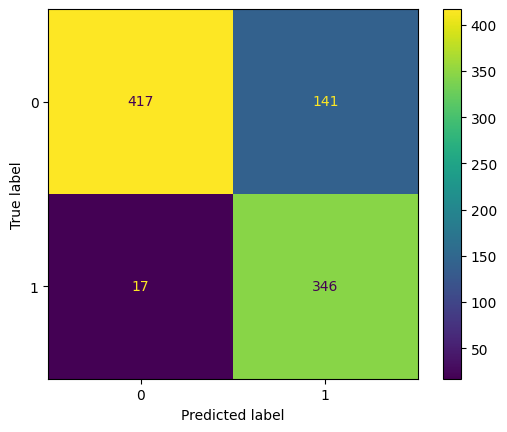

In [8]:
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ros', ROS(random_state=42)),# doit-on le maintenir ou pas? les classes ne sont pas déséquilibrées
    ('model', GaussianNB())
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

print("Naive Bayes\n")
print(classification_report(y_test, y_pred_nb))

cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
scores = cross_validate(
    nb_pipeline,
    X,
    y,
    cv=3,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)
scores_df = pd.DataFrame(scores)
print(scores_df)

Neural Network

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       558
           1       0.92      0.93      0.92       363

    accuracy                           0.94       921
   macro avg       0.93      0.94      0.94       921
weighted avg       0.94      0.94      0.94       921



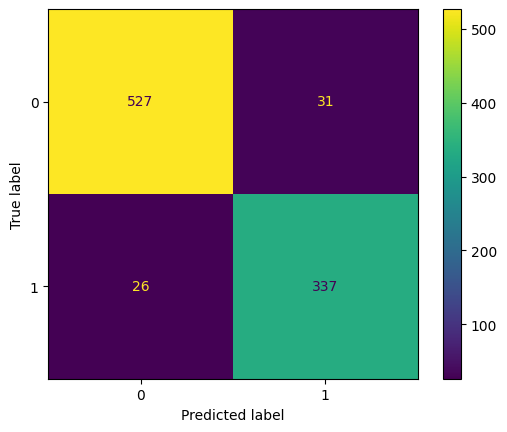

In [9]:


nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ros', ROS(random_state=42)),# doit-on le maintenir ou pas? les classes ne sont pas déséquilibrées
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),  # 2 couches cachées
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    ))
])

nn_pipeline.fit(X_train, y_train)
y_pred_nn = nn_pipeline.predict(X_test)

print("Neural Network\n")
print(classification_report(y_test, y_pred_nn))

cm = confusion_matrix(y_test, y_pred_nn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()